# 🫁 Global Asthma Analysis - Notebook
**Minia University — Graduation Project**  
**Dataset:** GBD 2023 · 204 Countries · 1990–2023  
**Rows:** 304,776 · **Columns:** 10

---
##  Notes
- `val` for Percent metric is decimal → multiply × 100 for display
---

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dark theme
plt.rcParams.update({
    'figure.facecolor':'#0b1120','axes.facecolor':'#111827',
    'axes.edgecolor':'#1f2d45','axes.labelcolor':'#94a3b8',
    'axes.titlecolor':'#e2e8f0','text.color':'#e2e8f0',
    'xtick.color':'#64748b','ytick.color':'#64748b',
    'grid.color':'#1f2d45','grid.linestyle':'--','grid.alpha':0.5,
    'axes.titlesize':13,'axes.labelsize':11,
    'legend.facecolor':'#1a2235','legend.edgecolor':'#1f2d45',
    'figure.dpi':120,
})

ACCENT  = '#38bdf8'
ACCENT2 = '#818cf8'
SUCCESS = '#34d399'
DANGER  = '#f87171'
WARNING = '#fbbf24'
PINK    = '#f472b6'
COLORS  = [ACCENT,ACCENT2,SUCCESS,WARNING,DANGER,'#a78bfa','#fb923c','#2dd4bf','#e879f9','#4ade80']

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ── Load ────────────────────────────────────────────────
# Put GBD_Asthma_Final.csv in the same folder as this notebook
df = pd.read_csv('GBD_Asthma_Final.csv')

# ── IMPORTANT: year is int64 ─────────────────────────────
# Always use: df['year'] == 2023  (integer, NOT '2023' string)
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'year dtype: {df["year"].dtype}  ← int64 (use integers in filters!)')
print(f'Years: {sorted(df["year"].unique())}')
df.head(3)

Rows: 304,776  |  Columns: 10
year dtype: int64  ← int64 (use integers in filters!)
Years: [np.int64(1990), np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2019), np.int64(2021), np.int64(2023)]


,measure_name,location_name,sex_name,age_name,cause_name,metric_name,year,val,upper,lower
0,Deaths,Papua New Guinea,Male,All ages,Asthma,Number,1995,263.511110,545.680071,76.241816
1,Deaths,Papua New Guinea,Female,All ages,Asthma,Number,1995,104.066036,250.059004,30.634837
2,Deaths,Papua New Guinea,Male,All ages,Asthma,Percent,1995,0.013148,0.027142,0.003842


## 2. Data Overview & Quality Check

In [3]:
print('=== COLUMN TYPES ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== UNIQUE VALUES ===')
for col in ['measure_name','metric_name','age_name','sex_name']:
    print(f'{col}: {sorted(df[col].unique())}')
print(f'Locations: {df["location_name"].nunique()} countries')

=== COLUMN TYPES ===
measure_name         str
location_name        str
sex_name             str
age_name             str
cause_name           str
metric_name          str
year               int64
val              float64
upper            float64
lower            float64
dtype: object

=== MISSING VALUES ===
measure_name     0
location_name    0
sex_name         0
age_name         0
cause_name       0
metric_name      0
year             0
val              0
upper            0
lower            0
dtype: int64

=== UNIQUE VALUES ===
measure_name: ['DALYs (Disability-Adjusted Life Years)', 'Deaths', 'Incidence', 'Prevalence', 'YLDs (Years Lived with Disability)']
metric_name: ['Number', 'Percent', 'Rate']
age_name: ['0-14 years', '15-49 years', '50-69 years', '70+ years', 'Age-standardized', 'All ages']
sex_name: ['Female', 'Male']
Locations: 204 countries


In [4]:
# ── Add helper columns ──────────────────────────────────
# val_display: converts Percent to readable % (0.052 → 5.2)
df['val_display'] = df.apply(
    lambda r: r['val'] * 100 if r['metric_name'] == 'Percent' else r['val'],
    axis=1
)

# ci_width: confidence interval width
df['ci_width'] = df['upper'] - df['lower']

# age_order: for correct sorting in charts
age_order_map = {
    '0-14 years':1,'15-49 years':2,'50-69 years':3,
    '70+ years':4,'All ages':5,'Age-standardized':6
}
df['age_order'] = df['age_name'].map(age_order_map)

AGE_GROUPS = ['0-14 years','15-49 years','50-69 years','70+ years']

print('✅ Helper columns added: val_display, ci_width, age_order')
print(df[['measure_name','metric_name','val','val_display']].head(6))

✅ Helper columns added: val_display, ci_width, age_order
  measure_name metric_name         val  val_display
0       Deaths      Number  263.511110   263.511110
1       Deaths      Number  104.066036   104.066036
2       Deaths     Percent    0.013148     1.314819
3       Deaths     Percent    0.006578     0.657840
4       Deaths        Rate   10.670384    10.670384
5       Deaths        Rate    4.540311     4.540311


## 3. Global Prevalence Trend (1990–2023)

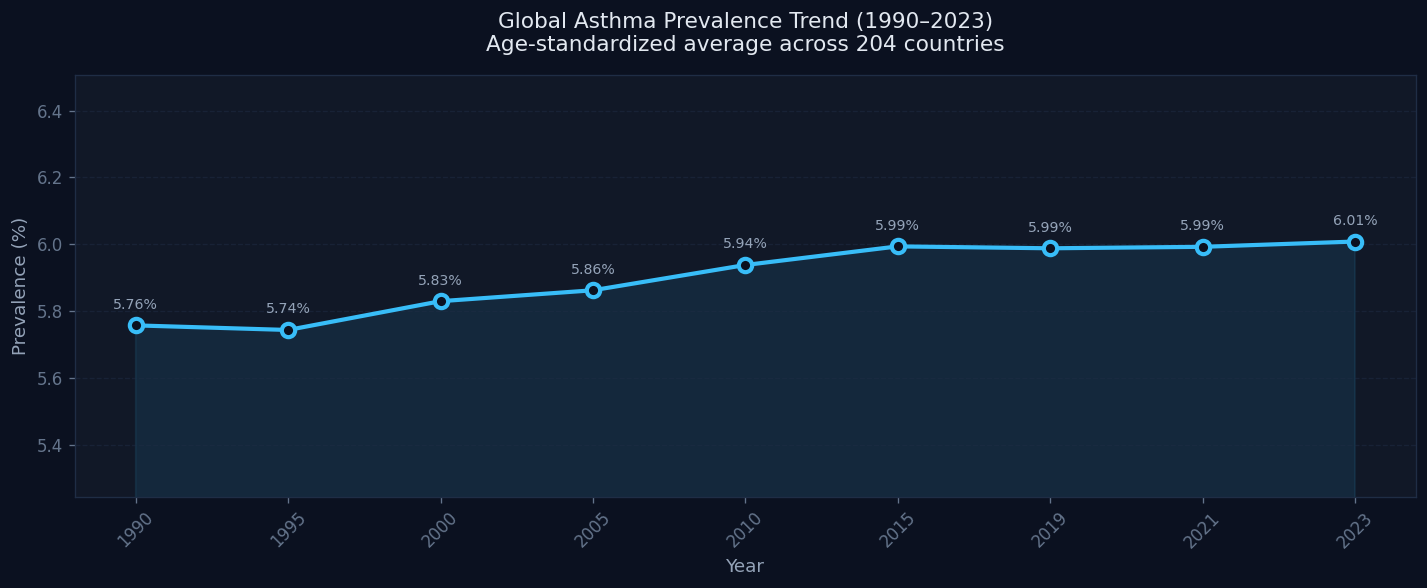

💾 Saved: chart1_prevalence_trend.png


In [5]:
prev_trend = (
    df[
        (df['measure_name'] == 'Prevalence') &
        (df['metric_name']  == 'Percent') &
        (df['age_name']     == 'Age-standardized')
    ]
    .groupby('year')['val_display']   # year is int — no quotes!
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
n = len(prev_trend)
xpos = range(n)

ax.plot(xpos, prev_trend['val_display'],
        color=ACCENT, linewidth=2.5, marker='o', markersize=8,
        markerfacecolor='#0b1120', markeredgewidth=2.5)
ax.fill_between(xpos, prev_trend['val_display'], alpha=0.1, color=ACCENT)

# Annotate each point
for i, row in prev_trend.iterrows():
    ax.annotate(f"{row['val_display']:.2f}%",
                xy=(i, row['val_display']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color='#94a3b8')

ax.set_xticks(list(xpos))
ax.set_xticklabels(prev_trend['year'].astype(str), rotation=45)
ax.set_title('Global Asthma Prevalence Trend (1990–2023)\nAge-standardized average across 204 countries', pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Prevalence (%)')
ax.grid(True, axis='y')
ax.set_ylim(prev_trend['val_display'].min() - 0.5, prev_trend['val_display'].max() + 0.5)
plt.tight_layout()
plt.savefig('chart1_prevalence_trend.png', dpi=150, bbox_inches='tight', facecolor='#0b1120')
plt.show()
print('💾 Saved: chart1_prevalence_trend.png')

## 4. Top 10 Countries by Prevalence (2023)

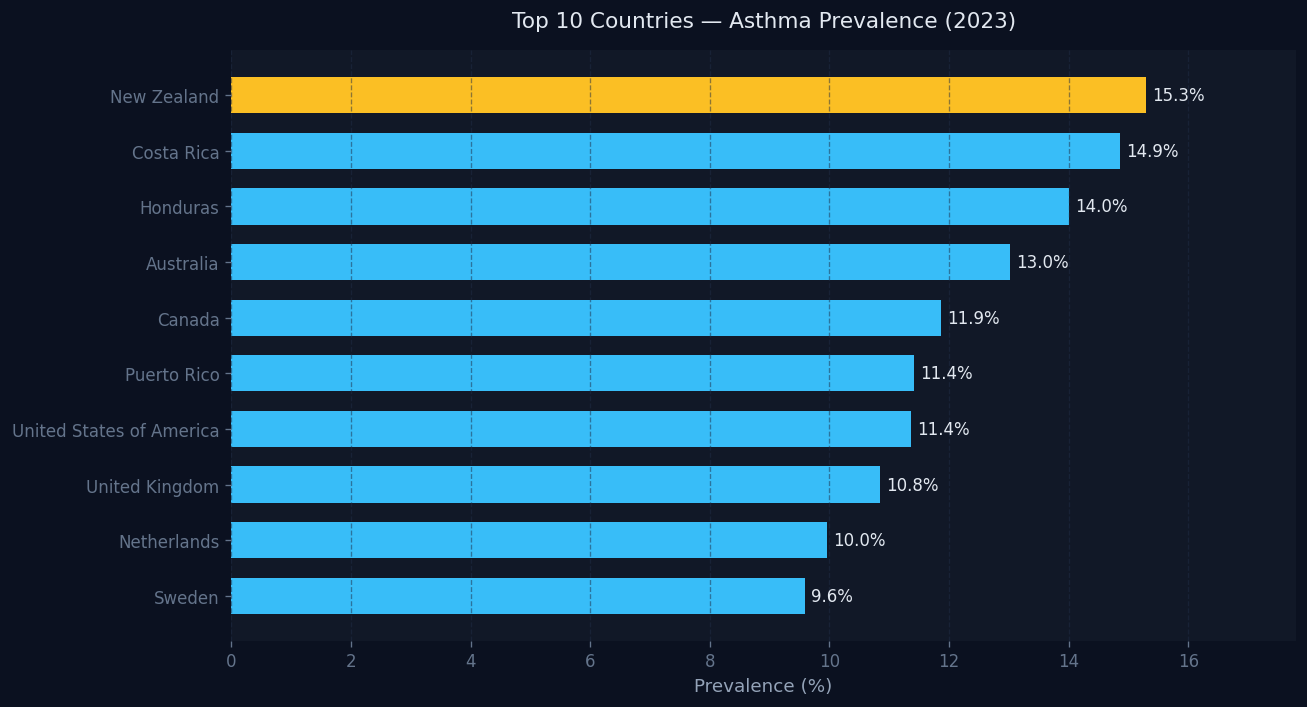

💾 Saved: chart2_top10_countries.png
           location_name  val_display
             New Zealand    15.300440
              Costa Rica    14.852276
                Honduras    14.009380
               Australia    13.016114
                  Canada    11.865044
             Puerto Rico    11.414180
United States of America    11.365170
          United Kingdom    10.843273
             Netherlands     9.963082
                  Sweden     9.590702


In [6]:
# ⚠️ FIX: year == 2023 (integer, not '2023' string)
top10 = (
    df[
        (df['year']         == 2023) &
        (df['measure_name'] == 'Prevalence') &
        (df['metric_name']  == 'Percent') &
        (df['age_name']     == 'All ages')
    ]
    .groupby('location_name')['val_display']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [WARNING] + [ACCENT] * 9
bars = ax.barh(
    top10['location_name'][::-1],
    top10['val_display'][::-1],
    color=bar_colors[::-1], edgecolor='none', height=0.65
)
for bar, val in zip(bars, top10['val_display'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color='#e2e8f0', fontsize=10)

ax.set_title('Top 10 Countries — Asthma Prevalence (2023)', pad=14)
ax.set_xlabel('Prevalence (%)')
ax.set_xlim(0, top10['val_display'].max() + 2.5)
ax.grid(True, axis='x')
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_top10_countries.png', dpi=150, bbox_inches='tight', facecolor='#0b1120')
plt.show()
print('💾 Saved: chart2_top10_countries.png')
print(top10.to_string(index=False))

## 5. Deaths Trend Over Time

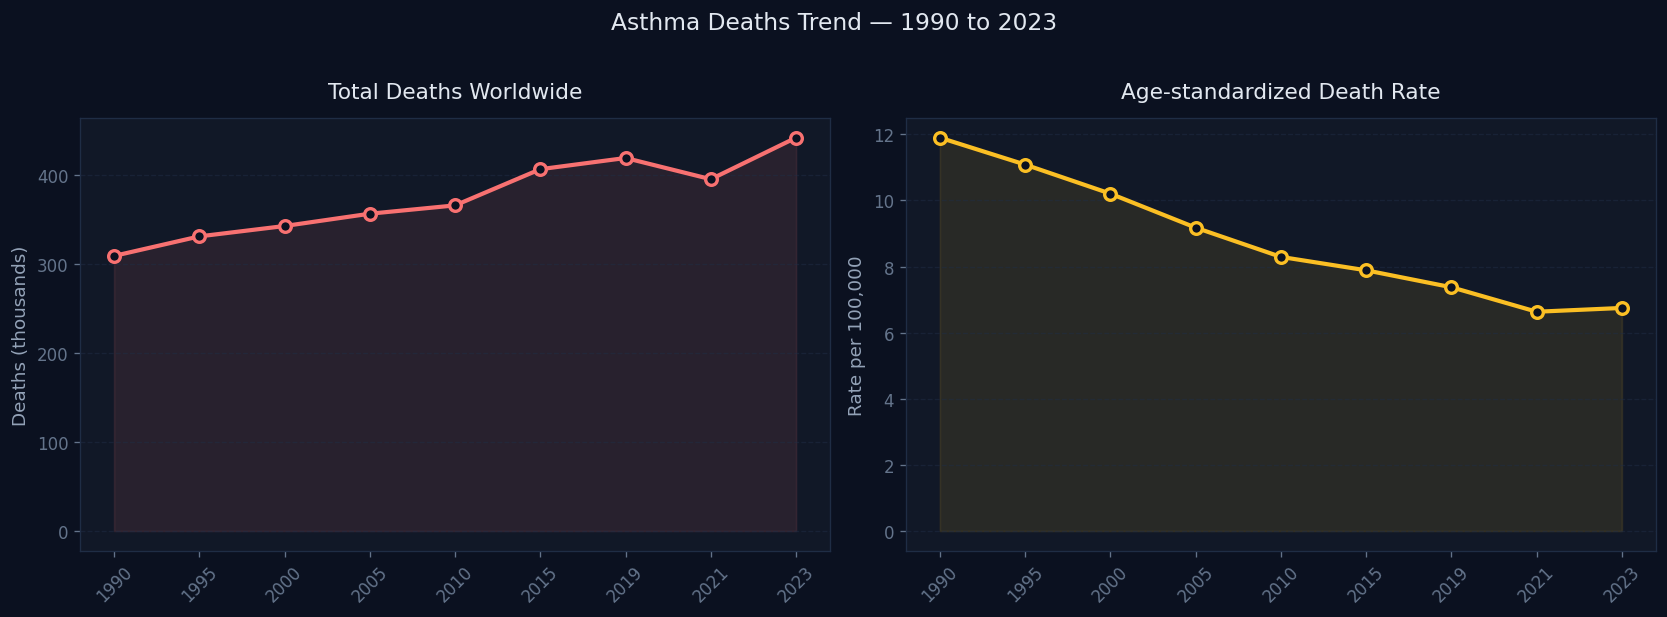

💾 Saved: chart3_deaths_trend.png


In [7]:
deaths_num = (
    df[
        (df['measure_name'] == 'Deaths') &
        (df['metric_name']  == 'Number') &
        (df['age_name']     == 'All ages')
    ]
    .groupby('year')['val']
    .sum()
    .reset_index()
)

deaths_rate = (
    df[
        (df['measure_name'] == 'Deaths') &
        (df['metric_name']  == 'Rate') &
        (df['age_name']     == 'Age-standardized')
    ]
    .groupby('year')['val']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, col, ylabel, title in [
    (axes[0], deaths_num, DANGER, 'Deaths (thousands)', 'Total Deaths Worldwide'),
    (axes[1], deaths_rate, WARNING, 'Rate per 100,000', 'Age-standardized Death Rate'),
]:
    yvals = data['val'] / 1000 if ylabel == 'Deaths (thousands)' else data['val']
    n = len(data)
    ax.plot(range(n), yvals, color=col, linewidth=2.5,
            marker='o', markersize=7, markerfacecolor='#0b1120', markeredgewidth=2)
    ax.fill_between(range(n), yvals, alpha=0.1, color=col)
    ax.set_xticks(range(n))
    ax.set_xticklabels(data['year'].astype(str), rotation=45)
    ax.set_title(title, pad=12)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis='y')

plt.suptitle('Asthma Deaths Trend — 1990 to 2023', fontsize=14, color='#e2e8f0', y=1.02)
plt.tight_layout()
plt.savefig('chart3_deaths_trend.png', dpi=150, bbox_inches='tight', facecolor='#0b1120')
plt.show()
print('💾 Saved: chart3_deaths_trend.png')

## 6. Age Group Comparison

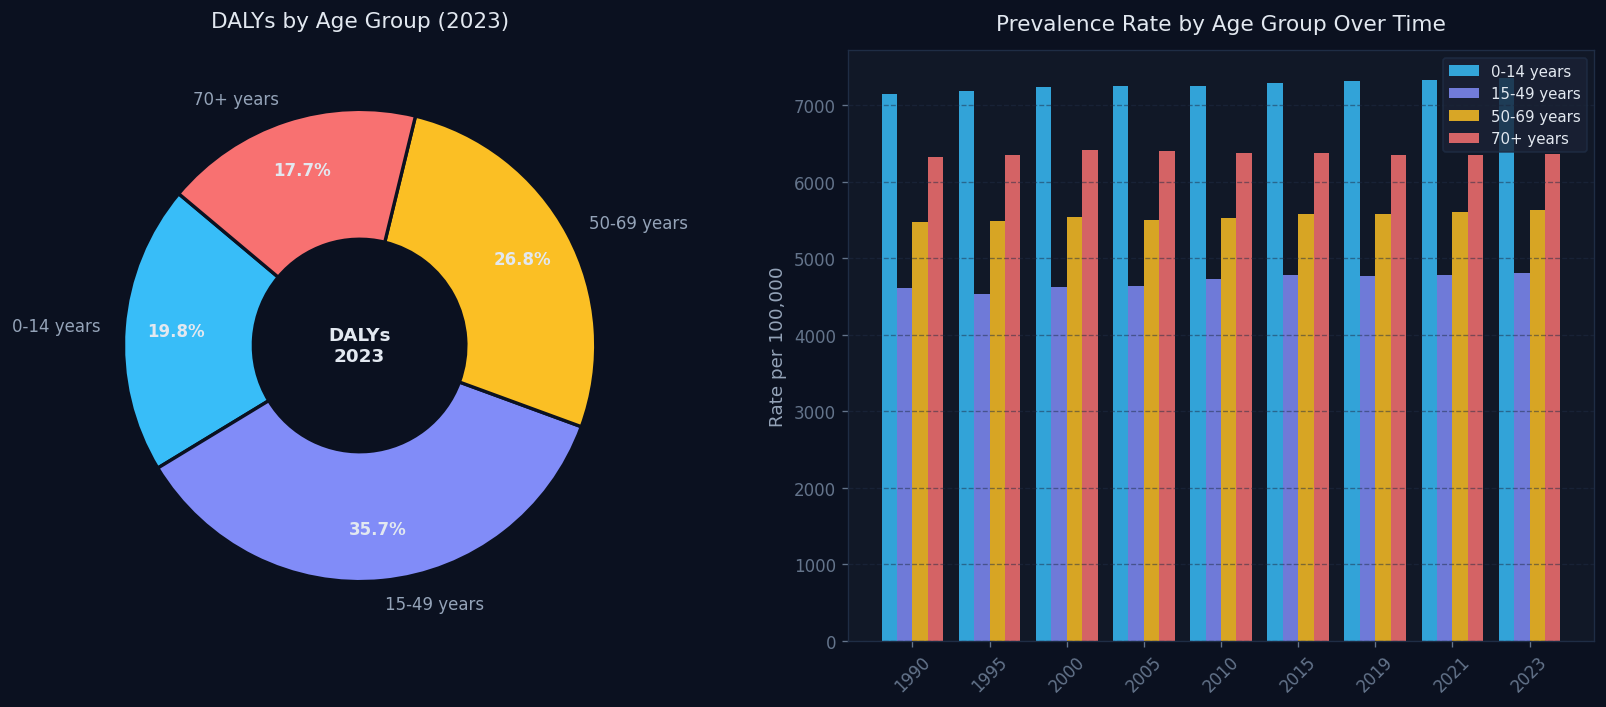

💾 Saved: chart4_age_groups.png


In [8]:
# ⚠️ FIX: year == 2023 integer
age_data = (
    df[
        (df['year']         == 2023) &
        (df['measure_name'] == 'DALYs (Disability-Adjusted Life Years)') &
        (df['metric_name']  == 'Number') &
        (df['age_name'].isin(AGE_GROUPS))
    ]
    .groupby('age_name')['val']
    .sum()
    .reindex(AGE_GROUPS)
    .reset_index()
)

prev_by_age = (
    df[
        (df['measure_name'] == 'Prevalence') &
        (df['metric_name']  == 'Rate') &
        (df['age_name'].isin(AGE_GROUPS))
    ]
    .groupby(['year','age_name'])['val']
    .mean()
    .unstack()
    .reindex(columns=AGE_GROUPS)
)

wedge_colors = [ACCENT, ACCENT2, WARNING, DANGER]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Donut
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    age_data['val'].fillna(0),
    labels=age_data['age_name'],
    colors=wedge_colors, autopct='%1.1f%%',
    pctdistance=0.78, startangle=140,
    wedgeprops={'width':0.55,'edgecolor':'#0b1120','linewidth':2}
)
for t in texts:     t.set_color('#94a3b8'); t.set_fontsize(10)
for at in autotexts: at.set_color('#e2e8f0'); at.set_fontweight('bold'); at.set_fontsize(10)
ax.text(0, 0, 'DALYs\n2023', ha='center', va='center',
        color='#e2e8f0', fontsize=11, fontweight='bold')
ax.set_title('DALYs by Age Group (2023)', pad=14)

# Grouped bar
ax2 = axes[1]
n = len(prev_by_age)
x = np.arange(n)
w = 0.2
for i, (age, color) in enumerate(zip(AGE_GROUPS, wedge_colors)):
    ax2.bar(x + i*w, prev_by_age[age].values, width=w,
            label=age, color=color, alpha=0.85, edgecolor='none')

ax2.set_xticks(x + 1.5*w)
ax2.set_xticklabels(prev_by_age.index.astype(str), rotation=45)
ax2.set_title('Prevalence Rate by Age Group Over Time', pad=12)
ax2.set_ylabel('Rate per 100,000')
ax2.legend(fontsize=9)
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('chart4_age_groups.png', dpi=150, bbox_inches='tight', facecolor='#0b1120')
plt.show()
print('💾 Saved: chart4_age_groups.png')

## 7. Male vs Female Comparison

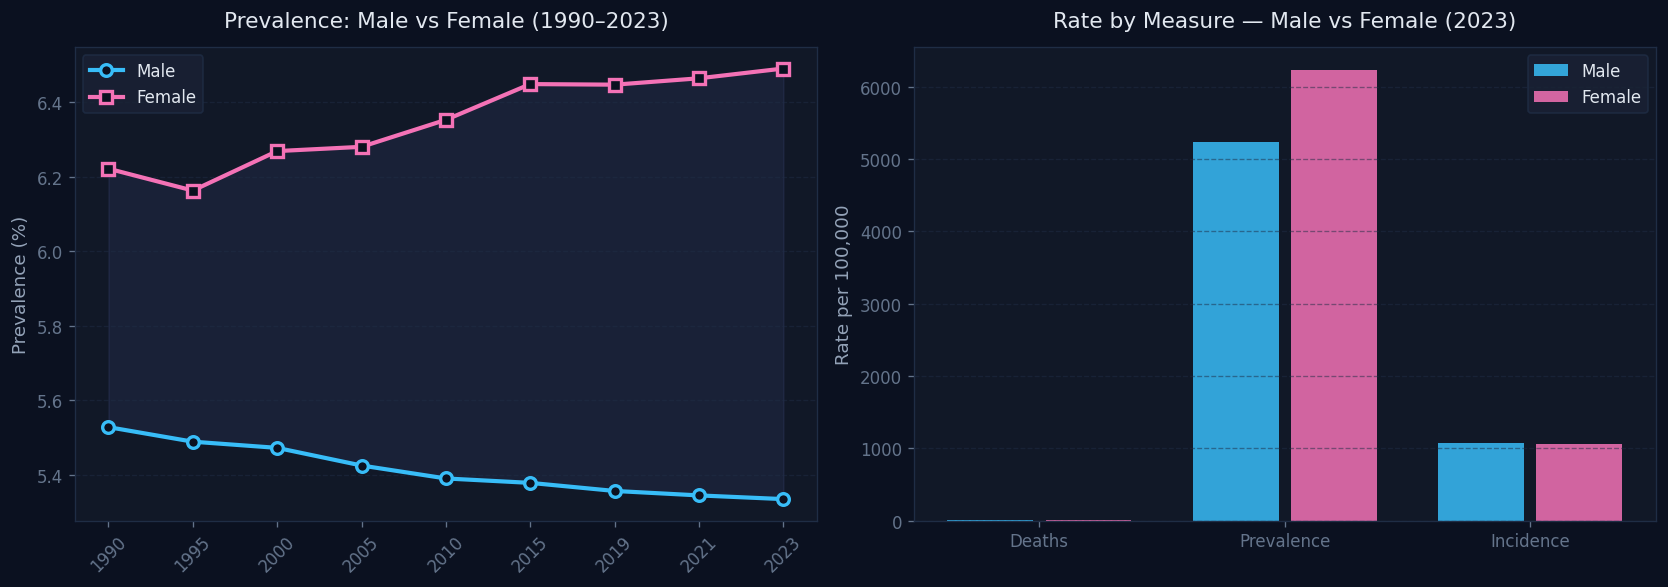

💾 Saved: chart5_male_female.png


In [9]:
sex_trend = (
    df[
        (df['measure_name'] == 'Prevalence') &
        (df['metric_name']  == 'Percent') &
        (df['age_name']     == 'All ages')
    ]
    .groupby(['year','sex_name'])['val_display']
    .mean()
    .unstack()
)

# ⚠️ FIX: year == 2023 integer
measures_compare = ['Deaths','Prevalence','Incidence']
sex_measure = (
    df[
        (df['year']         == 2023) &
        (df['metric_name']  == 'Rate') &
        (df['age_name']     == 'Age-standardized') &
        (df['measure_name'].isin(measures_compare))
    ]
    .groupby(['measure_name','sex_name'])['val']
    .mean()
    .unstack()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line trend
ax = axes[0]
n = len(sex_trend)
ax.plot(range(n), sex_trend['Male'].values,
        color=ACCENT, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor='#0b1120', markeredgewidth=2, label='Male')
ax.plot(range(n), sex_trend['Female'].values,
        color=PINK, linewidth=2.5, marker='s', markersize=7,
        markerfacecolor='#0b1120', markeredgewidth=2, label='Female')
ax.fill_between(range(n), sex_trend['Male'].values,
                sex_trend['Female'].values, alpha=0.08, color=ACCENT2)
ax.set_xticks(range(n))
ax.set_xticklabels(sex_trend.index.astype(str), rotation=45)
ax.set_title('Prevalence: Male vs Female (1990–2023)', pad=12)
ax.set_ylabel('Prevalence (%)')
ax.legend(); ax.grid(True, axis='y')

# Clustered bar 2023
ax2 = axes[1]
x2 = np.arange(len(measures_compare))
ax2.bar(x2 - 0.2, sex_measure.reindex(measures_compare)['Male'],
        width=0.35, label='Male', color=ACCENT, alpha=0.85)
ax2.bar(x2 + 0.2, sex_measure.reindex(measures_compare)['Female'],
        width=0.35, label='Female', color=PINK, alpha=0.85)
ax2.set_xticks(list(x2))
ax2.set_xticklabels(measures_compare)
ax2.set_title('Rate by Measure — Male vs Female (2023)', pad=12)
ax2.set_ylabel('Rate per 100,000')
ax2.legend(); ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('chart5_male_female.png', dpi=150, bbox_inches='tight', facecolor='#0b1120')
plt.show()
print('💾 Saved: chart5_male_female.png')

## 8. Heatmap — Top 20 Countries × Measures

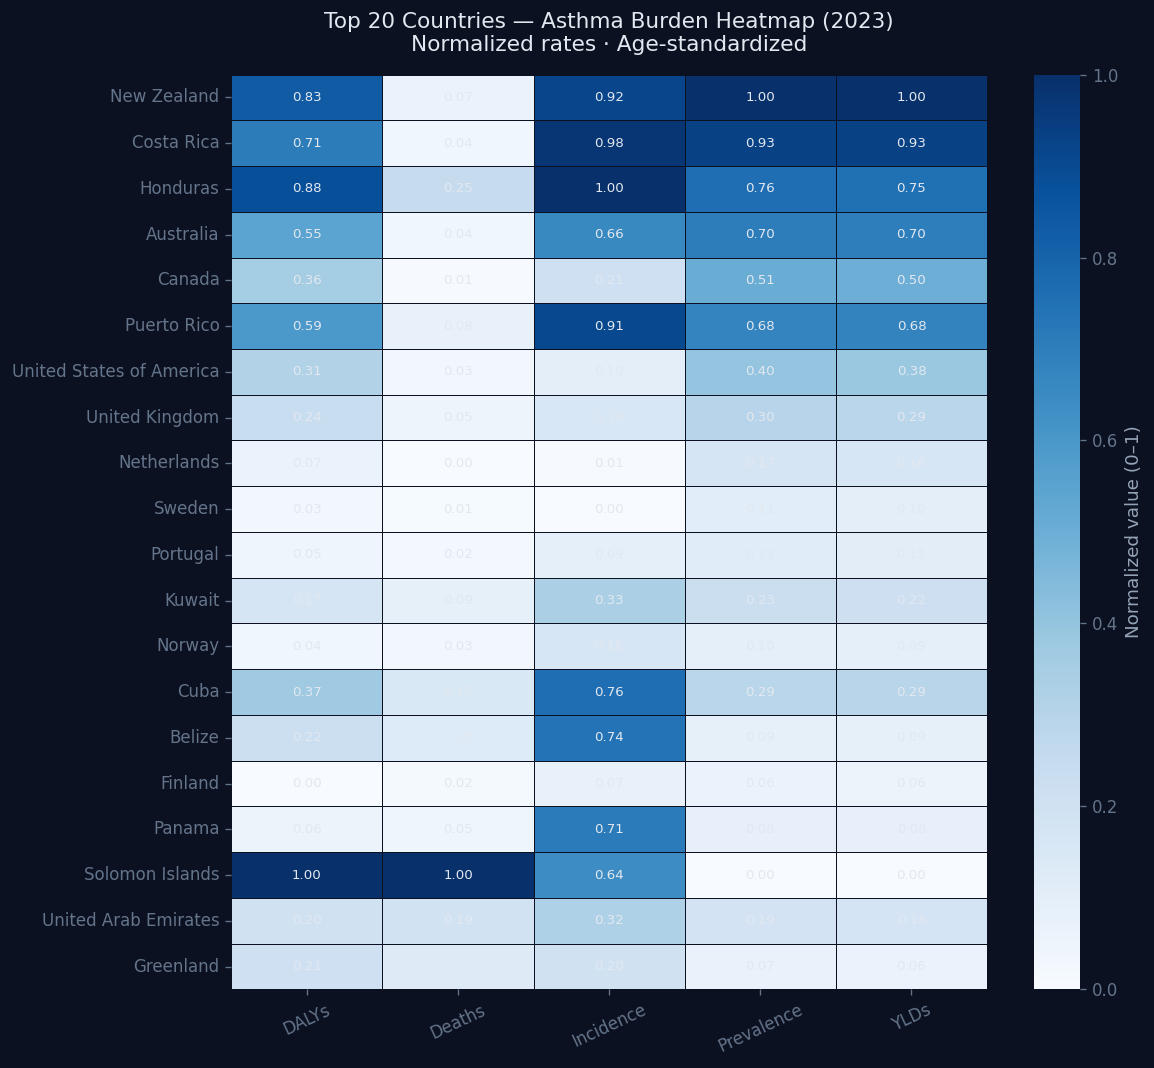

💾 Saved: chart6_heatmap.png


In [10]:
# ⚠️ FIX: year == 2023 integer
top20_locs = (
    df[
        (df['year']         == 2023) &
        (df['measure_name'] == 'Prevalence') &
        (df['metric_name']  == 'Percent') &
        (df['age_name']     == 'All ages')
    ]
    .groupby('location_name')['val_display']
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

short = {
    'Deaths':'Deaths','Prevalence':'Prevalence','Incidence':'Incidence',
    'DALYs (Disability-Adjusted Life Years)':'DALYs',
    'YLDs (Years Lived with Disability)':'YLDs'
}
measures_list = list(short.keys())

hm = (
    df[
        (df['year']         == 2023) &
        (df['metric_name']  == 'Rate') &
        (df['age_name']     == 'Age-standardized') &
        (df['location_name'].isin(top20_locs)) &
        (df['measure_name'].isin(measures_list))
    ]
    .groupby(['location_name','measure_name'])['val']
    .mean()
    .unstack()
    .rename(columns=short)
    .reindex(top20_locs)
)

hm_norm = (hm - hm.min()) / (hm.max() - hm.min())

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    hm_norm, ax=ax, cmap='Blues',
    linewidths=0.4, linecolor='#0b1120',
    annot=True, fmt='.2f', annot_kws={'size':8,'color':'#e2e8f0'},
    cbar_kws={'label':'Normalized value (0–1)'}
)
ax.set_title('Top 20 Countries — Asthma Burden Heatmap (2023)\nNormalized rates · Age-standardized', pad=14)
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0b1120')
plt.show()
print('💾 Saved: chart6_heatmap.png')

## 9. Egypt Deep Dive 🇪🇬

Egypt rows: 1494


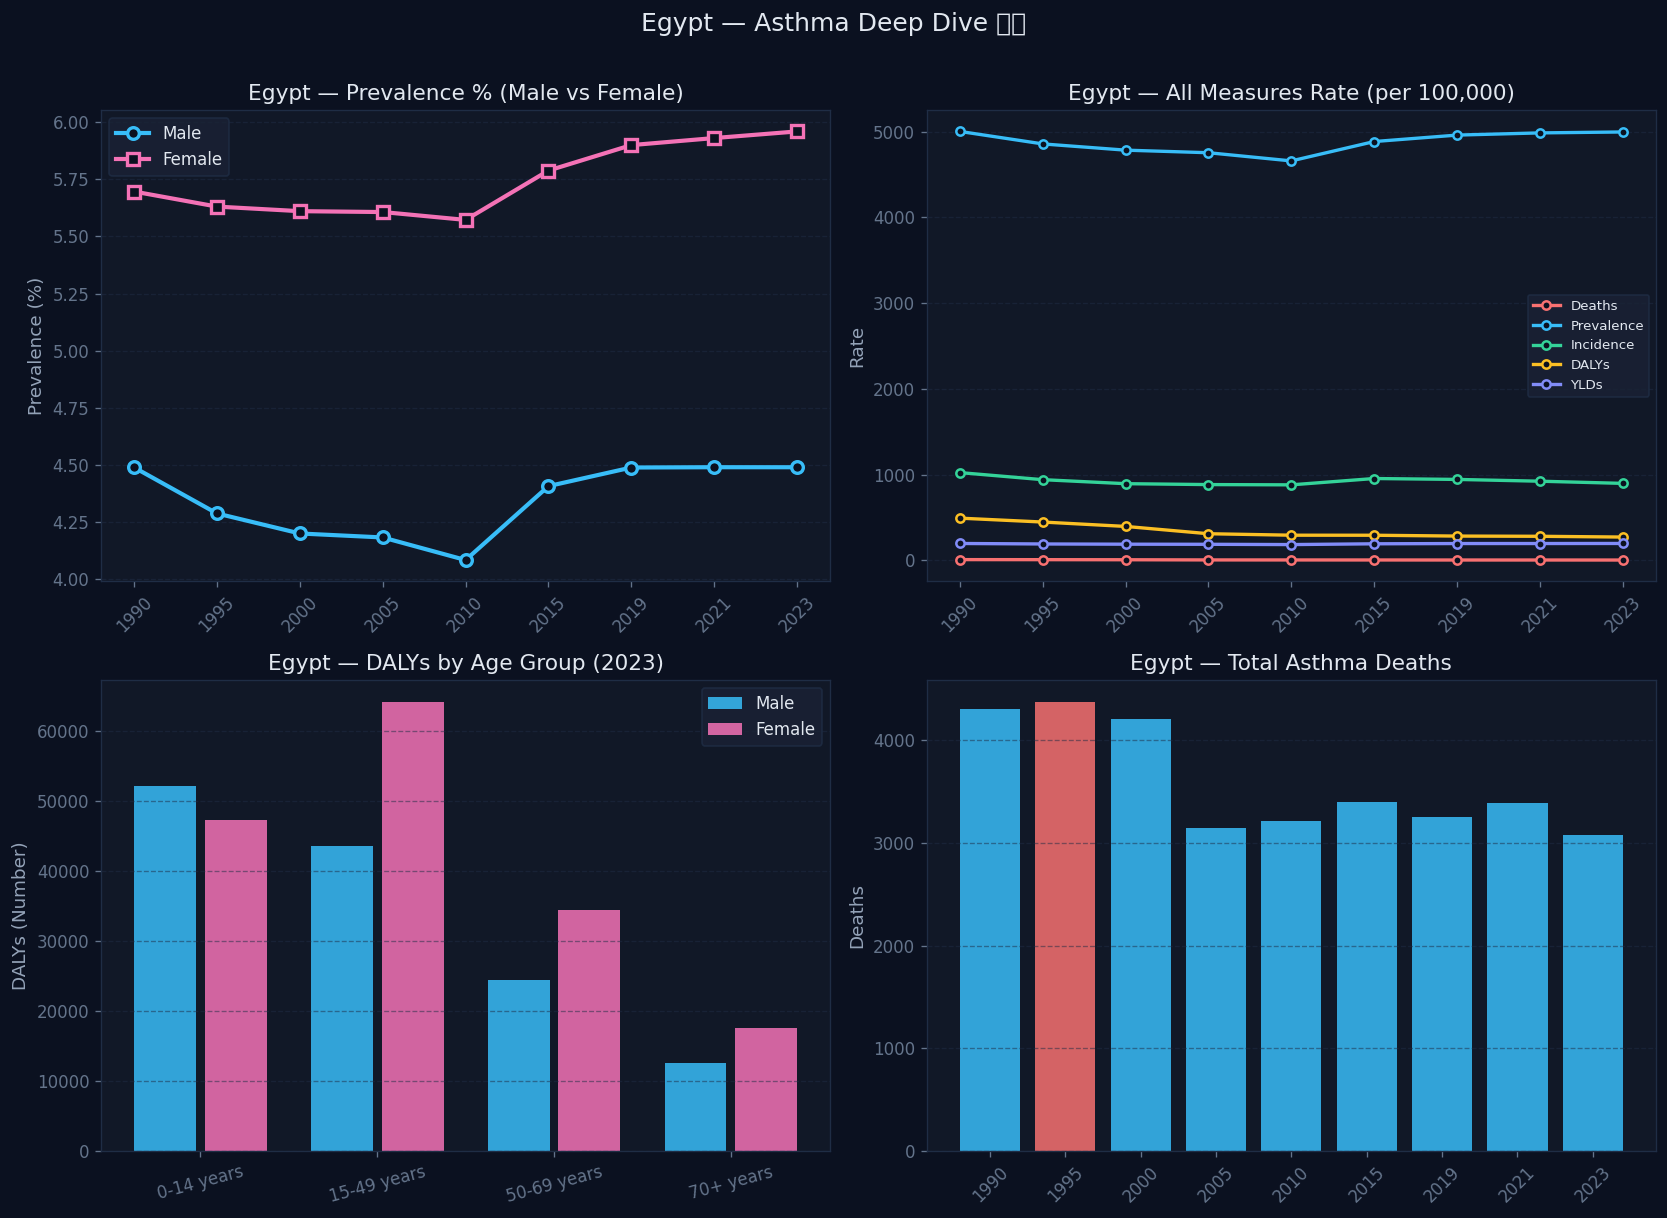

💾 Saved: chart7_egypt.png


In [11]:
egypt = df[df['location_name'] == 'Egypt'].copy()
egypt['val_display'] = egypt.apply(
    lambda r: r['val']*100 if r['metric_name']=='Percent' else r['val'], axis=1
)
print(f'Egypt rows: {len(egypt)}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Egypt — Asthma Deep Dive 🇪🇬', fontsize=15, color='#e2e8f0', y=1.01)

# 1) Prevalence Male vs Female trend
ax = axes[0,0]
eg_prev = egypt[
    (egypt['measure_name']=='Prevalence') &
    (egypt['metric_name'] =='Percent') &
    (egypt['age_name']    =='All ages')
].pivot_table(index='year', columns='sex_name', values='val_display')

n = len(eg_prev)
ax.plot(range(n), eg_prev['Male'].values,
        color=ACCENT, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor='#0b1120', markeredgewidth=2, label='Male')
ax.plot(range(n), eg_prev['Female'].values,
        color=PINK, linewidth=2.5, marker='s', markersize=7,
        markerfacecolor='#0b1120', markeredgewidth=2, label='Female')
ax.set_xticks(range(n))
ax.set_xticklabels(eg_prev.index.astype(str), rotation=45)
ax.set_title('Egypt — Prevalence % (Male vs Female)')
ax.set_ylabel('Prevalence (%)')
ax.legend(); ax.grid(True, axis='y')

# 2) All measures rate trend
ax2 = axes[0,1]
eg_meas = egypt[
    (egypt['metric_name']=='Rate') &
    (egypt['age_name']   =='All ages')
].groupby(['year','measure_name'])['val'].mean().unstack()

mcolors2 = {
    'Deaths':DANGER,'Prevalence':ACCENT,'Incidence':SUCCESS,
    'DALYs (Disability-Adjusted Life Years)':WARNING,
    'YLDs (Years Lived with Disability)':ACCENT2
}
n2 = len(eg_meas)
for measure, color in mcolors2.items():
    if measure in eg_meas.columns:
        lbl = 'DALYs' if 'DALY' in measure else ('YLDs' if 'YLD' in measure else measure)
        ax2.plot(range(n2), eg_meas[measure].values,
                 color=color, linewidth=2, marker='o', markersize=5,
                 markerfacecolor='#0b1120', markeredgewidth=1.5, label=lbl)
ax2.set_xticks(range(n2))
ax2.set_xticklabels(eg_meas.index.astype(str), rotation=45)
ax2.set_title('Egypt — All Measures Rate (per 100,000)')
ax2.set_ylabel('Rate')
ax2.legend(fontsize=8); ax2.grid(True, axis='y')

# 3) DALYs by age group 2023
ax3 = axes[1,0]
eg_age = egypt[
    (egypt['year']         == 2023) &
    (egypt['measure_name'] == 'DALYs (Disability-Adjusted Life Years)') &
    (egypt['metric_name']  == 'Number') &
    (egypt['age_name'].isin(AGE_GROUPS))
].groupby(['age_name','sex_name'])['val'].sum().unstack().reindex(AGE_GROUPS)

x3 = np.arange(len(AGE_GROUPS))
ax3.bar(x3 - 0.2, eg_age['Male'],   width=0.35, label='Male',   color=ACCENT, alpha=0.85)
ax3.bar(x3 + 0.2, eg_age['Female'], width=0.35, label='Female', color=PINK,   alpha=0.85)
ax3.set_xticks(list(x3))
ax3.set_xticklabels(AGE_GROUPS, rotation=15)
ax3.set_title('Egypt — DALYs by Age Group (2023)')
ax3.set_ylabel('DALYs (Number)')
ax3.legend(); ax3.grid(True, axis='y')

# 4) Deaths bar chart
ax4 = axes[1,1]
eg_deaths = egypt[
    (egypt['measure_name']=='Deaths') &
    (egypt['metric_name'] =='Number') &
    (egypt['age_name']    =='All ages')
].groupby('year')['val'].sum()

bar_cols = [DANGER if v==eg_deaths.max() else ACCENT for v in eg_deaths.values]
ax4.bar(eg_deaths.index.astype(str), eg_deaths.values,
        color=bar_cols, alpha=0.85, edgecolor='none')
ax4.set_title('Egypt — Total Asthma Deaths')
ax4.set_ylabel('Deaths')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, axis='y')

plt.tight_layout()
plt.savefig('chart7_egypt.png', dpi=150, bbox_inches='tight', facecolor='#0b1120')
plt.show()
print('💾 Saved: chart7_egypt.png')

## 10. Summary Statistics & Key Findings

In [12]:
print('=' * 55)
print('  GLOBAL ASTHMA — KEY FINDINGS')
print('=' * 55)

# Total deaths 2023
d = df[(df['year']==2023)&(df['measure_name']=='Deaths')&
       (df['metric_name']=='Number')&(df['age_name']=='All ages')]['val'].sum()
print(f'Total Deaths (2023):        {d:>14,.0f}')

# Global prevalence
p = df[(df['year']==2023)&(df['measure_name']=='Prevalence')&
       (df['metric_name']=='Percent')&(df['age_name']=='Age-standardized')]['val_display'].mean()
print(f'Avg Global Prevalence:      {p:>13.2f}%')

# Top country
tc = df[(df['year']==2023)&(df['measure_name']=='Prevalence')&
        (df['metric_name']=='Percent')&(df['age_name']=='All ages')
       ].groupby('location_name')['val_display'].mean()
print(f'Highest Prevalence Country: {tc.idxmax()} ({tc.max():.1f}%)')

# Egypt
eg = df[(df['year']==2023)&(df['location_name']=='Egypt')&
        (df['measure_name']=='Prevalence')&(df['metric_name']=='Percent')&
        (df['age_name']=='All ages')]['val_display'].mean()
print(f'Egypt Prevalence (2023):    {eg:>13.2f}%')

# Gender
gf = df[(df['year']==2023)&(df['measure_name']=='Prevalence')&
        (df['metric_name']=='Percent')&(df['age_name']=='All ages')&
        (df['sex_name']=='Female')]['val_display'].mean()
gm = df[(df['year']==2023)&(df['measure_name']=='Prevalence')&
        (df['metric_name']=='Percent')&(df['age_name']=='All ages')&
        (df['sex_name']=='Male')]['val_display'].mean()
print(f'Female Prevalence avg:      {gf:>13.2f}%')
print(f'Male Prevalence avg:        {gm:>13.2f}%')
print(f'Gender Gap (F - M):         {gf-gm:>+12.2f}%')

# Total DALYs
dalys = df[(df['year']==2023)&
           (df['measure_name']=='DALYs (Disability-Adjusted Life Years)')&
           (df['metric_name']=='Number')&(df['age_name']=='All ages')]['val'].sum()
print(f'Total DALYs (2023):         {dalys:>14,.0f}')

print('=' * 55)
print('Charts saved: chart1 through chart7')
print('=' * 55)

  GLOBAL ASTHMA — KEY FINDINGS
Total Deaths (2023):               441,663
Avg Global Prevalence:               6.01%
Highest Prevalence Country: New Zealand (15.3%)
Egypt Prevalence (2023):             5.22%
Female Prevalence avg:               6.49%
Male Prevalence avg:                 5.33%
Gender Gap (F - M):                +1.16%
Total DALYs (2023):             25,823,803
Charts saved: chart1 through chart7
